In [1]:
import sys
import numpy	as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn
import optuna

from xgboost	import XGBClassifier
from sklearn.metrics	import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

sys.path.append('..')
X_train, X_test, y_train, y_test = joblib.load('../data/processed/train_test_split.pkl')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class distribution: {y_train.value_counts().to_dict()}")
print(f"Class distribution: {y_test.value_counts().to_dict()}")

Train: (800, 33), Test: (200, 33)
Class distribution: {0: 559, 1: 241}
Class distribution: {0: 141, 1: 59}


In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos  # ~2.32, real imbalance ratio

def objective(trial):
  params = {
    "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    "max_depth": trial.suggest_int("max_depth", 3, 8),
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
    "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    "gamma": trial.suggest_float("gamma", 0.0, 3.0),
    "scale_pos_weight": spw,
    "eval_metric": "logloss",
    "random_state": 42,
  }

  model = XGBClassifier(**params)
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
  scores = cross_val_score(
    model, X_train, y_train,
    cv=cv, scoring="f1", n_jobs=-1
  )
  return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best CV F1: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-03-20 13:15:16,785] A new study created in memory with name: no-name-e10e1460-6a7f-4966-85b8-5f5a00d52781


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-20 13:15:19,428] Trial 0 finished with value: 0.6036530946881674 and parameters: {'n_estimators': 241, 'max_depth': 3, 'learning_rate': 0.010011045315773263, 'subsample': 0.9826592018592011, 'colsample_bytree': 0.9758042242691042, 'min_child_weight': 1, 'gamma': 1.860924036679271}. Best is trial 0 with value: 0.6036530946881674.
[I 2026-03-20 13:15:19,703] Trial 1 finished with value: 0.6047197253915122 and parameters: {'n_estimators': 465, 'max_depth': 7, 'learning_rate': 0.012484709625288264, 'subsample': 0.8549900287413947, 'colsample_bytree': 0.73659759972035, 'min_child_weight': 9, 'gamma': 2.2993470175713444}. Best is trial 1 with value: 0.6047197253915122.
[I 2026-03-20 13:15:19,971] Trial 2 finished with value: 0.5706738809640926 and parameters: {'n_estimators': 474, 'max_depth': 6, 'learning_rate': 0.03141868770382898, 'subsample': 0.825041985287909, 'colsample_bytree': 0.9571545565108188, 'min_child_weight': 10, 'gamma': 1.6066360768195247}. Best is trial 1 with va

In [3]:
best_params = study.best_params
best_params["scale_pos_weight"] = spw
best_params["eval_metric"] = "logloss"
best_params["random_state"] = 42

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)
  
y_pred = xgb_tuned.predict(X_test)
y_pred_proba = xgb_tuned.predict_proba(X_test)[:, 1]
  
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"CV F1 (Optuna): 0.6299")
print(f"Test F1: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

CV F1 (Optuna): 0.6299
Test F1: 0.6573
Test ROC-AUC: 0.8406
              precision    recall  f1-score   support

           0       0.90      0.74      0.81       141
           1       0.56      0.80      0.66        59

    accuracy                           0.76       200
   macro avg       0.73      0.77      0.73       200
weighted avg       0.80      0.76      0.76       200

[[104  37]
 [ 12  47]]


In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}, F1: {f1_scores[best_idx]:.4f}")

print("\n=== Threshold Sensitivity ===")
for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
  y_t = (y_pred_proba >= t).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, y_t).ravel()
  f1 = f1_score(y_test, y_t)
  print(f"t={t:.2f} | F1={f1:.4f} | Recall(bad)={tp/(tp+fn):.2f} | FN={fn} | FP={fp}")

Best threshold: 0.4577, F1: 0.6753

=== Threshold Sensitivity ===
t=0.30 | F1=0.5588 | Recall(bad)=0.97 | FN=2 | FP=88
t=0.35 | F1=0.6188 | Recall(bad)=0.95 | FN=3 | FP=66
t=0.40 | F1=0.6358 | Recall(bad)=0.93 | FN=4 | FP=59
t=0.45 | F1=0.6752 | Recall(bad)=0.90 | FN=6 | FP=45
t=0.50 | F1=0.6573 | Recall(bad)=0.80 | FN=12 | FP=37


In [5]:
threshold = 0.45
with mlflow.start_run(run_name="XGBoost_Threshold_Tuned"):
    y_pred_final = (y_pred_proba >= threshold).astype(int)
    
    f1 = f1_score(y_test, y_pred_final)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
    
    mlflow.log_param("threshold", threshold)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("false_negatives", fn)
    mlflow.log_metric("false_positives", fp)
    mlflow.log_metric("recall_bad_credit", tp / (tp + fn))
    
    print("=== Final Model Threshold ===")
    print(f"Threshold:      {threshold}")
    print(f"F1 Score:       {f1:.4f}")
    print(f"ROC-AUC:        {roc_auc:.4f}")
    print(f"Recall (bad):   {tp/(tp+fn):.2f}  → catching {tp} of {tp+fn} defaulters")
    print(f"False Negatives: {fn}  → bad loans approved")
    print(f"False Positives: {fp}  → good loans rejected")
    print(classification_report(y_test, y_pred_final))
    print(confusion_matrix(y_test, y_pred_final))

=== Final Model Threshold ===
Threshold:      0.45
F1 Score:       0.6752
ROC-AUC:        0.8406
Recall (bad):   0.90  → catching 53 of 59 defaulters
False Negatives: 6  → bad loans approved
False Positives: 45  → good loans rejected
              precision    recall  f1-score   support

           0       0.94      0.68      0.79       141
           1       0.54      0.90      0.68        59

    accuracy                           0.74       200
   macro avg       0.74      0.79      0.73       200
weighted avg       0.82      0.74      0.76       200

[[96 45]
 [ 6 53]]


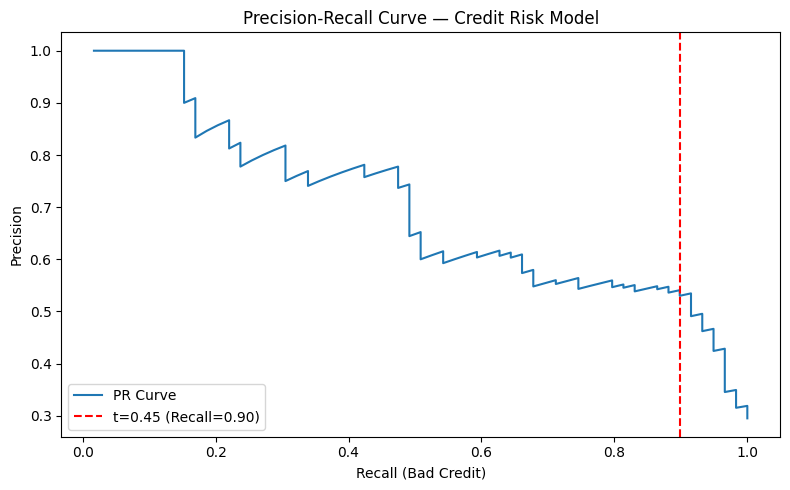

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(recall[:-1], precision[:-1], label="PR Curve")
plt.axvline(x=tp/(tp+fn), color='red', linestyle='--', label=f"t=0.45 (Recall={tp/(tp+fn):.2f})")
plt.xlabel("Recall (Bad Credit)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Credit Risk Model")
plt.legend()
plt.tight_layout()
plt.savefig('../models/pr_curve.png')
plt.show()

In [15]:
import json

joblib.dump(xgb_tuned, '../models/xgb_final.pkl')

model_config = {
  "threshold": 0.45,
  "n_estimators": 121,
  "max_depth": 4,
  "learning_rate": 0.0183,
  "scale_pos_weight": round(spw, 4),
  "f1_score": 0.6752,
  "roc_auc": 0.8406,
  "recall_bad_credit": 0.90,
  "false_negatives": 6,
  "false_positives": 45
}

with open('../models/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Model and config saved.")
print(json.dumps(model_config, indent=2))

Model and config saved.
{
  "threshold": 0.45,
  "n_estimators": 121,
  "max_depth": 4,
  "learning_rate": 0.0183,
  "scale_pos_weight": 2.3195,
  "f1_score": 0.6752,
  "roc_auc": 0.8406,
  "recall_bad_credit": 0.9,
  "false_negatives": 6,
  "false_positives": 45
}


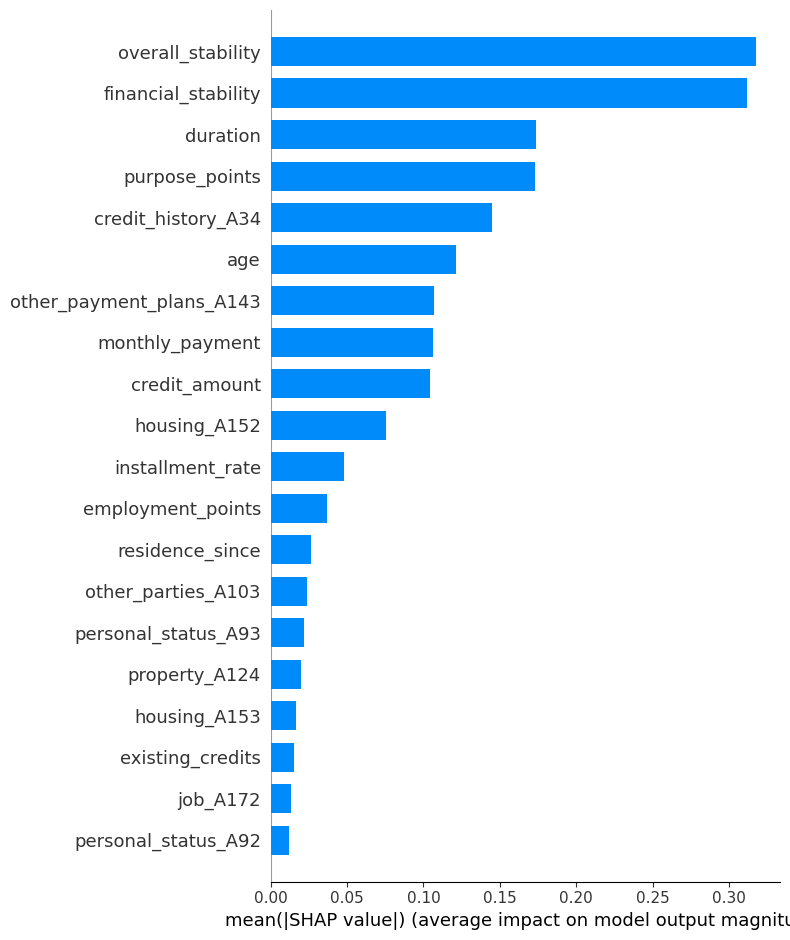

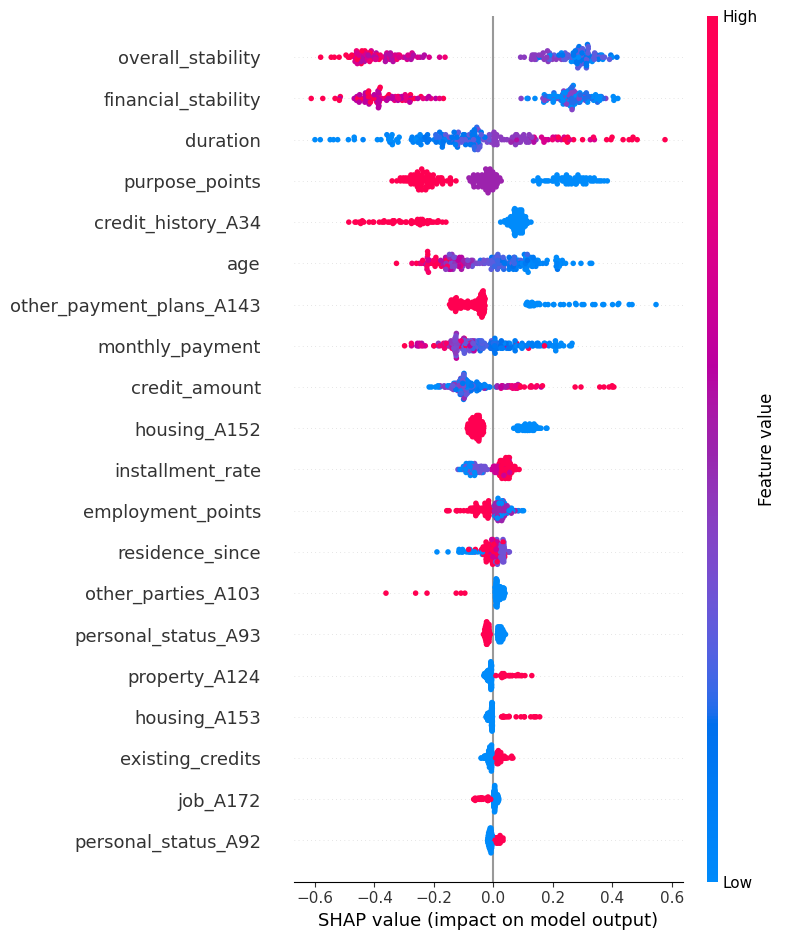

In [12]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('../models/shap_importance.png')
plt.show()

# Detailed summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../models/shap_summary.png')
plt.show()


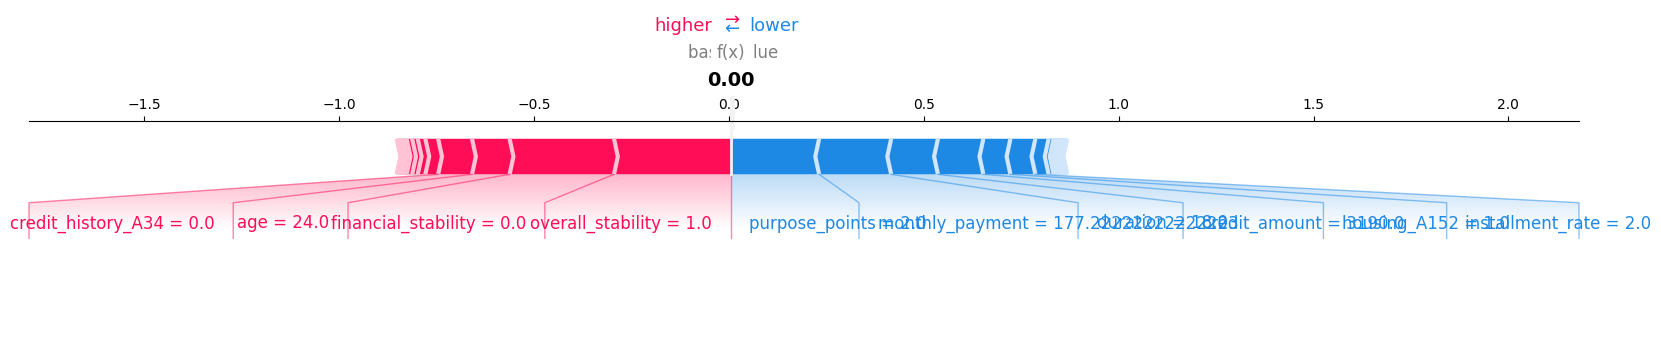

<Figure size 640x480 with 0 Axes>

In [13]:
# Single prediction explanation (first test sample)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)
plt.savefig('../models/shap_force_plot.png')
plt.show()

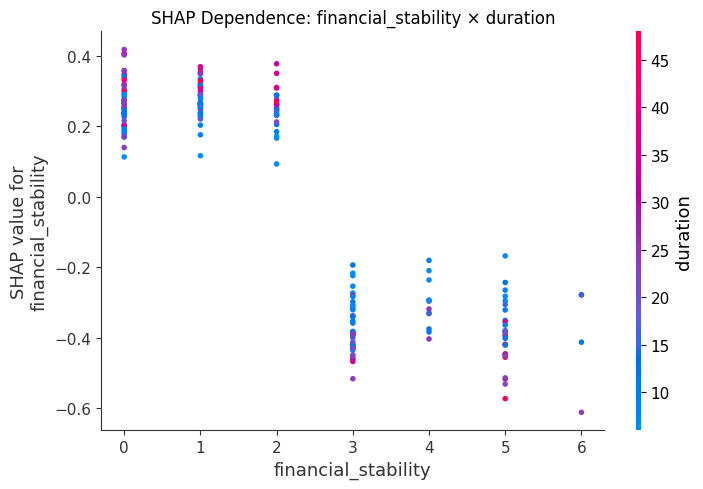

In [14]:
shap.dependence_plot(
  "financial_stability",
  shap_values,
		X_test,
  interaction_index="duration",
  show=False
)

plt.title("SHAP Dependence: financial_stability × duration")
plt.tight_layout()
plt.savefig('../models/shap_dependence.png')
plt.show()